In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../outputs/customer_final.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

required = ['CustomerID', 'Recency', 'Frequency', 'Monetary',
            'AOV', 'UniqueProducts', 'Lifespan', 'CLTV', 'CLTV_Tier',
            'Churned', 'Churn_Probability', 'Churn_Risk',
            'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment',
            'Cluster', 'Cluster_Name']

missing_cols=[c for c in required if c not in df.columns]

if missing_cols:
    print(f"\nMISSING COLUMNS: {missing_cols}")
    print("Re-run the relevant phase before continuing.")
    
else:
    print("\nAll required columns present.")
    
df.head()


Shape: (4228, 27)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AOV', 'UniqueProducts', 'Lifespan', 'AvgDaysBetweenOrders', 'CLTV', 'CLTV_Tier', 'Churned', 'Log_Recency', 'Log_Frequency', 'Log_Monetary', 'Log_AOV', 'Log_CLTV', 'F_Score', 'M_Score', 'R_Score', 'RFM_Score', 'RFM_Label', 'Segment', 'Churn Probability', 'Churn_Probability', 'Churn_Risk', 'Cluster', 'Cluster_Name']

All required columns present.


,CustomerID,Recency,Frequency,Monetary,AOV,UniqueProducts,Lifespan,AvgDaysBetweenOrders,CLTV,CLTV_Tier,...,M_Score,R_Score,RFM_Score,RFM_Label,Segment,Churn Probability,Churn_Probability,Churn_Risk,Cluster,Cluster_Name
0,12347,2,7,3783.23,21.495625,101,365,60.833333,300.938750,High,...,5,5,15,555,Champion,0.047957,0.047957,Low,0,Mid Value
1,12348,249,3,90.20,15.033333,6,109,54.500000,58.568219,Mid,...,1,1,5,131,Hibernating,0.498511,0.498511,Medium,1,Low Value
2,12349,19,1,1328.55,19.537500,68,0,0.000000,19.537500,Low,...,4,4,9,414,New Customer,0.395317,0.395317,Medium,1,Low Value
3,12350,310,1,294.40,18.400000,16,0,0.000000,18.400000,Low,...,2,1,4,112,Lost,0.548192,0.548192,Medium,1,Low Value
4,12352,36,7,1321.99,17.626533,56,260,43.333333,211.276941,High,...,4,3,12,354,Needs Attention,0.116130,0.116130,Low,0,Mid Value


In [4]:
df_sorted=df.sort_values('Monetary',ascending=False).reset_index(drop=True)
df_sorted['Cumulative_Revenue']=df_sorted['Monetary'].cumsum()
df_sorted['Cumulative_Revenue_%']=(df_sorted['Cumulative_Revenue']/df_sorted['Monetary'].sum()*100)
df_sorted['Customer_%']=((df_sorted.index+1)/len(df_sorted)*100)

threshold_80=df_sorted[df_sorted['Cumulative_Revenue_%']>=80].index[0]+1
pct_customers=threshold_80/len(df_sorted)*100

print("PARETO ANALYSIS")
print(f"Top {pct_customers:.1f}% of customers generate 80% of total revenue")
print(f"That is {threshold_80:,} customers out of {len(df_sorted):,}")
print(f"\nTotal revenue: £{df['Monetary'].sum():,.0f}")
print(f"Top 10 customers revenue: £{df_sorted['Monetary'].head(10).sum():,.0f}")
print(f"Top 10 share: {df_sorted['Monetary'].head(10).sum()/df['Monetary'].sum()*100:.1f}%")


PARETO ANALYSIS
Top 33.8% of customers generate 80% of total revenue
That is 1,429 customers out of 4,228

Total revenue: £5,309,791
Top 10 customers revenue: £405,954
Top 10 share: 7.6%


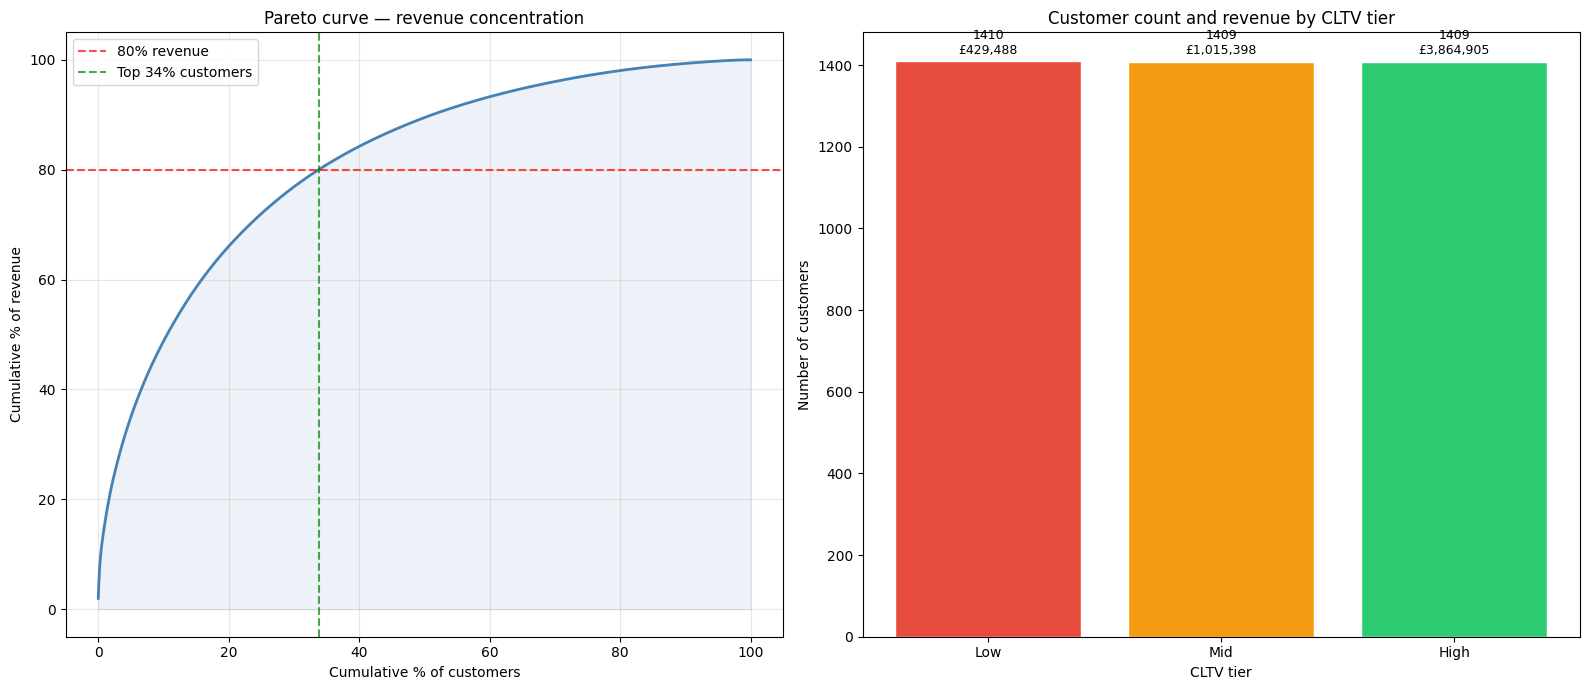

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pareto curve
axes[0].plot(df_sorted['Customer_%'],df_sorted['Cumulative_Revenue_%'],color='steelblue', linewidth=2)
axes[0].axhline(80, color='red', linestyle='--', alpha=0.7, label='80% revenue')
axes[0].axvline(pct_customers, color='green', linestyle='--',alpha=0.7, label=f'Top {pct_customers:.0f}% customers')
axes[0].fill_between(df_sorted['Customer_%'],df_sorted['Cumulative_Revenue_%'],alpha=0.1, color='steelblue')
axes[0].set_xlabel('Cumulative % of customers')
axes[0].set_ylabel('Cumulative % of revenue')
axes[0].set_title('Pareto curve — revenue concentration')
axes[0].legend()
axes[0].grid(alpha=0.3)

# CLTV distribution by tier
tier_order = ['Low', 'Mid', 'High']
tier_counts = df['CLTV_Tier'].value_counts().reindex(tier_order)
tier_colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[1].bar(tier_order, tier_counts.values,color=tier_colors, edgecolor='white')

for i, (tier, count) in enumerate(zip(tier_order, tier_counts.values)):
    revenue = df[df['CLTV_Tier'] == tier]['Monetary'].sum()
    axes[1].text(i, count + 10, f'{count}\n£{revenue:,.0f}',ha='center', va='bottom', fontsize=9)
axes[1].set_title('Customer count and revenue by CLTV tier')
axes[1].set_ylabel('Number of customers')
axes[1].set_xlabel('CLTV tier')

plt.tight_layout()
plt.savefig('../outputs/insights_pareto.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
top10 = df.nlargest(10, 'CLTV')[
    ['CustomerID', 'Recency', 'Frequency', 'Monetary','CLTV', 'Churn_Probability', 'Segment', 'Cluster_Name']
].reset_index(drop=True)

top10.index += 1
print("TOP 10 CUSTOMERS BY CLTV")
print(top10.to_string())

TOP 10 CUSTOMERS BY CLTV
    CustomerID  Recency  Frequency   Monetary         CLTV  Churn_Probability          Segment Cluster_Name
1        14911        1        195  105017.20  8125.259099           0.047957         Champion   High Value
2        15061        4         39   15357.11  6833.961762           0.047957         Champion   High Value
3        14646        2         56   30094.18  5964.909369           0.047957         Champion   High Value
4        13408        2         59   16127.88  5256.799108           0.047957         Champion   High Value
5        12971        4         82    7746.00  5081.930645           0.047957         Champion   High Value
6        15189        1         41    9503.69  4762.860868           0.047957         Champion   High Value
7        16422       17         44    8551.04  4731.154973           0.047957         Champion   High Value
8        13089        4         86   45685.51  4635.052252           0.047957         Champion   High Value
9  

In [12]:
high_risk = df[df['Churn_Risk'] == 'High']
medium_risk = df[df['Churn_Risk'] == 'Medium']
low_risk = df[df['Churn_Risk'] == 'Low']

total_revenue = df['Monetary'].sum()

print("CHURN RISK ANALYSIS")
print(f"\n{'Risk Tier':<12} {'Customers':>10} {'Revenue':>12} {'% of Total':>11}")
print("-" * 50)
for tier_name, tier_df in [('High', high_risk),
                             ('Medium', medium_risk),
                             ('Low', low_risk)]:
    rev = tier_df['Monetary'].sum()
    print(f"{tier_name:<12} {len(tier_df):>10,} "
          f"£{rev:>11,.0f} {rev/total_revenue*100:>10.1f}%")
print("-" * 50)
print(f"{'Total':<12} {len(df):>10,} £{total_revenue:>11,.0f} {'100.0':>10}%")

CHURN RISK ANALYSIS

Risk Tier     Customers      Revenue  % of Total
--------------------------------------------------
High                 53 £      2,943        0.1%
Medium            2,416 £  1,000,908       18.9%
Low               1,759 £  4,305,939       81.1%
--------------------------------------------------
Total             4,228 £  5,309,791      100.0%


In [13]:
urgent = df[
    (df['Churn_Risk'] == 'High') &
    (df['CLTV_Tier'] == 'High')
].sort_values('Monetary', ascending=False)

print(f"\nHIGH VALUE + HIGH CHURN RISK (most urgent):")
print(f"Count: {len(urgent)} customers")
print(f"Revenue at stake: £{urgent['Monetary'].sum():,.0f}")
print(f"Avg CLTV: £{urgent['CLTV'].mean():,.0f}")
print(f"\nTop 10 most urgent customers:")
print(urgent[['CustomerID','Monetary','CLTV',
              'Churn_Probability','Segment','Cluster_Name']]
      .head(10).to_string(index=False))


HIGH VALUE + HIGH CHURN RISK (most urgent):
Count: 11 customers
Revenue at stake: £1,443
Avg CLTV: £131

Top 10 most urgent customers:
 CustomerID  Monetary   CLTV  Churn_Probability      Segment Cluster_Name
      16144    175.20 175.20           0.607480  Hibernating    Low Value
      16976    175.20 175.20           0.607480  Hibernating    Low Value
      17331    175.20 175.20           0.607480  Hibernating    Low Value
      16716    166.80 166.80           0.607480  Hibernating    Low Value
      15562    134.55 134.55           0.609106         Lost    Low Value
      15269    118.80 118.80           0.609036 New Customer    Low Value
      15070    106.20 106.20           0.606888         Lost    Low Value
      15171    102.00 102.00           0.606888         Lost    Low Value
      13188     99.60  99.60           0.606888 New Customer    Low Value
      13703     99.50  99.50           0.606888         Lost    Low Value


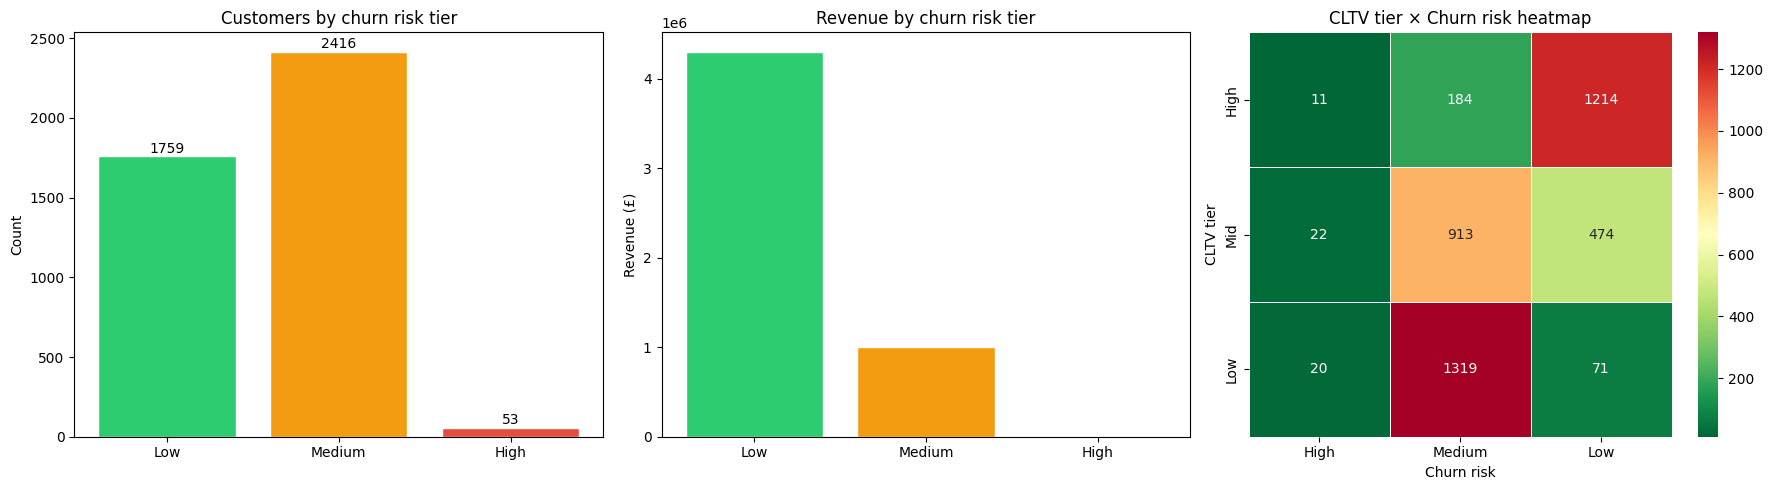

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Churn risk distribution
risk_counts=df['Churn_Risk'].value_counts().reindex(['Low','Medium','High'])
axes[0].bar(['Low','Medium','High'],risk_counts.values,color=['#2ecc71','#f39c12','#e74c3c'],edgecolor='white')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom')
axes[0].set_title('Customers by churn risk tier')
axes[0].set_ylabel('Count')

# Revenue at stake by risk tier
rev_by_risk = df.groupby('Churn_Risk')['Monetary'].sum().reindex(['Low','Medium','High'])

axes[1].bar(['Low','Medium','High'],rev_by_risk.values,color=['#2ecc71','#f39c12','#e74c3c'],edgecolor='white')
axes[1].set_title('Revenue by churn risk tier')
axes[1].set_ylabel('Revenue (£)')

# Churn risk × CLTV tier heatmap
cross = pd.crosstab(df['CLTV_Tier'], df['Churn_Risk'])
cross = cross.reindex(index=['High','Mid','Low'],columns=['High','Medium','Low'],fill_value=0)
sns.heatmap(cross, annot=True, fmt='d', cmap='RdYlGn_r',ax=axes[2], linewidths=0.5)
axes[2].set_title('CLTV tier × Churn risk heatmap')
axes[2].set_xlabel('Churn risk')
axes[2].set_ylabel('CLTV tier')

plt.tight_layout()
plt.savefig('../outputs/insights_churn_risk.png', dpi=100, bbox_inches='tight')
plt.show()

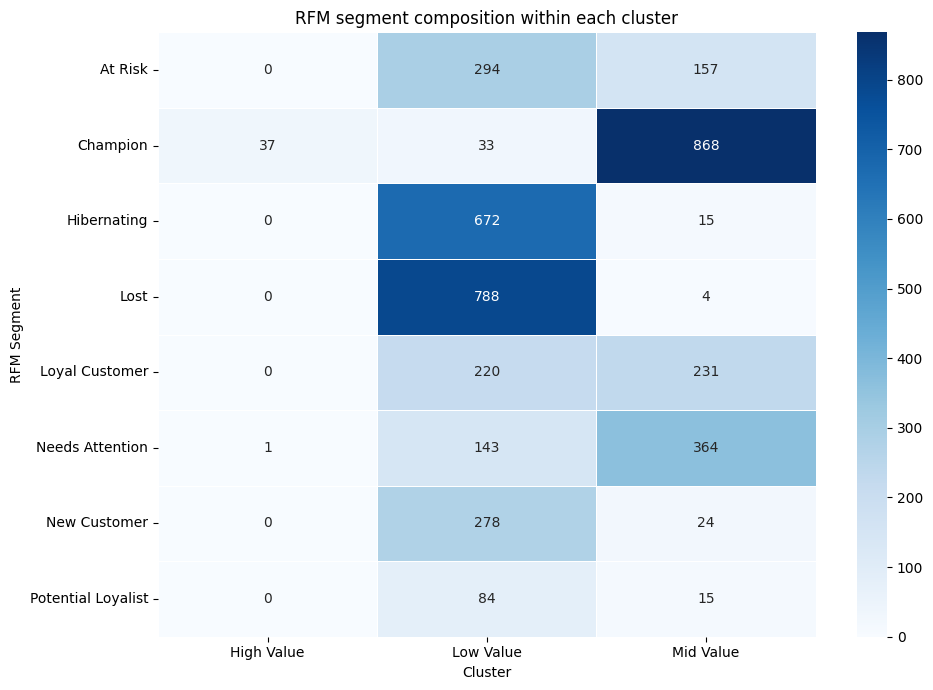

In [15]:
cross_seg_cluster = pd.crosstab(df['Segment'], df['Cluster_Name'])

plt.figure(figsize=(10, 7))
sns.heatmap(
    cross_seg_cluster,
    annot=True, fmt='d',
    cmap='Blues',
    linewidths=0.5
)
plt.title('RFM segment composition within each cluster')
plt.ylabel('RFM Segment')
plt.xlabel('Cluster')
plt.tight_layout()
plt.savefig('../outputs/insights_segment_cluster_heatmap.png',dpi=100,bbox_inches='tight')
plt.show()

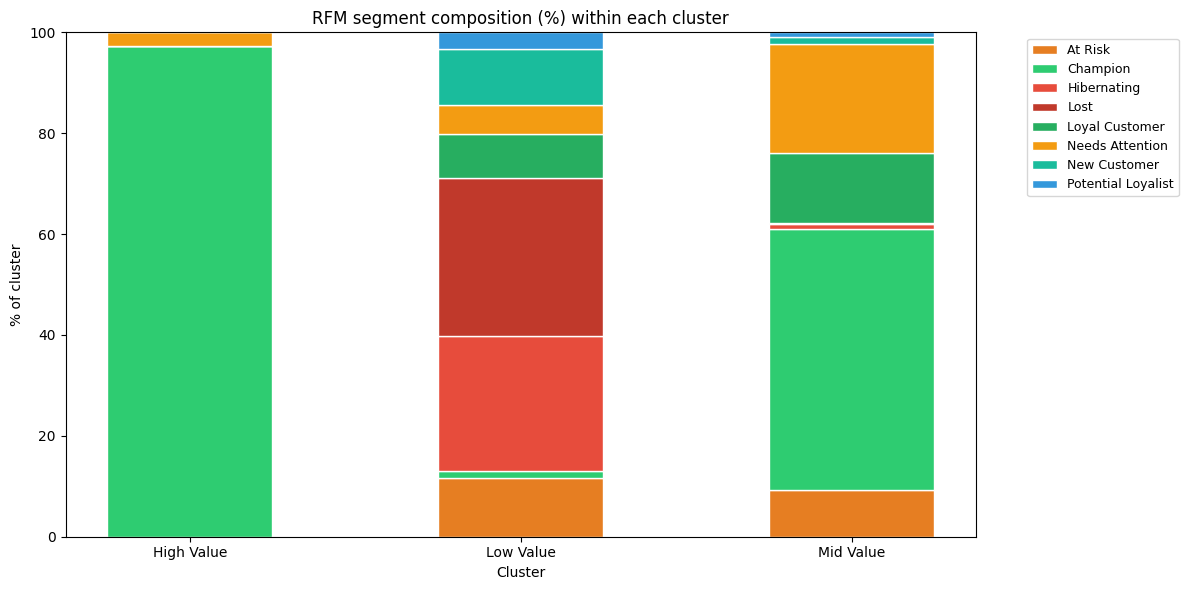

In [16]:
cross_pct = cross_seg_cluster.div(cross_seg_cluster.sum(axis=0), axis=1) * 100

SEGMENT_COLORS = {
    'Champion':          '#2ecc71',
    'Loyal Customer':    '#27ae60',
    'Potential Loyalist':'#3498db',
    'New Customer':      '#1abc9c',
    'Needs Attention':   '#f39c12',
    'At Risk':           '#e67e22',
    'Hibernating':       '#e74c3c',
    'Lost':              '#c0392b',
}

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(cross_pct.columns))

for segment in cross_pct.index:
    values = cross_pct.loc[segment].values
    color = SEGMENT_COLORS.get(segment, '#95a5a6')
    bars = ax.bar(cross_pct.columns, values, bottom=bottom,
                  label=segment, color=color, edgecolor='white', width=0.5)
    bottom += values

ax.set_ylabel('% of cluster')
ax.set_xlabel('Cluster')
ax.set_title('RFM segment composition (%) within each cluster')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/insights_segment_cluster_stacked.png',
            dpi=100, bbox_inches='tight')
plt.show()

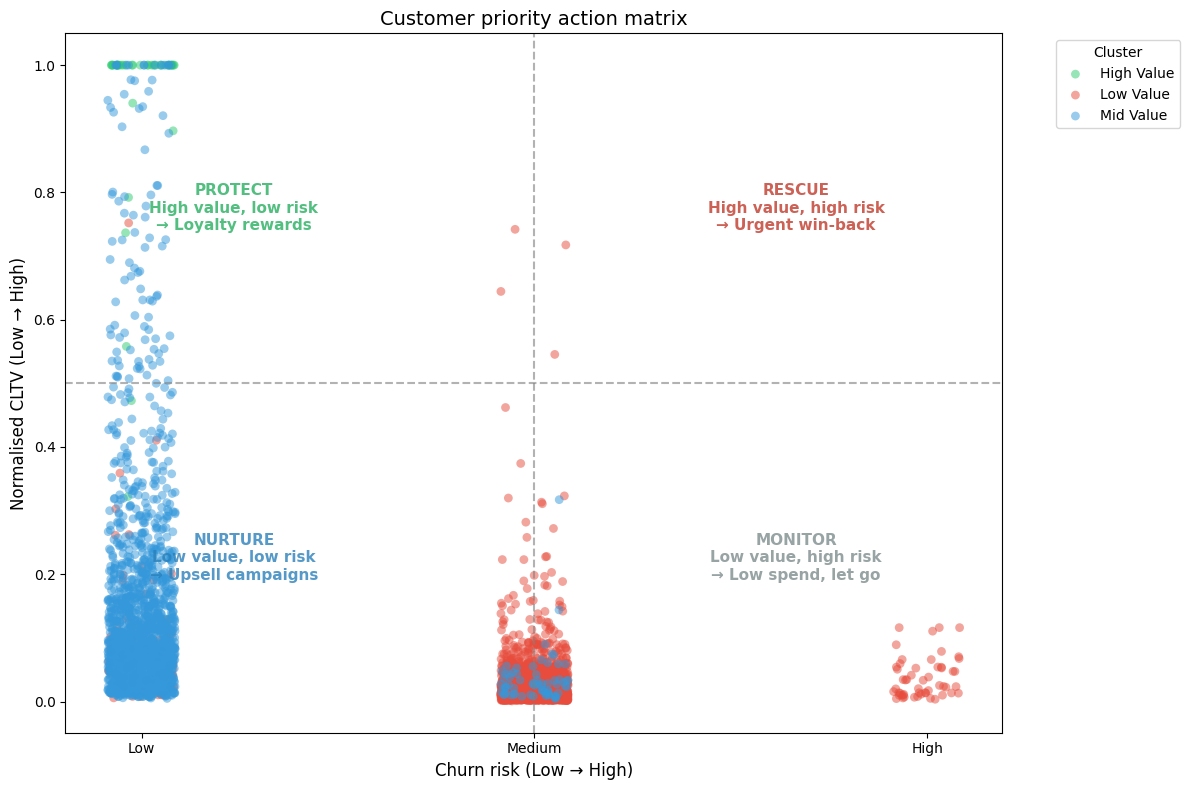

In [17]:
risk_map = {'Low': 0.15, 'Medium': 0.5, 'High': 0.85}
df['Churn_Risk_Num'] = df['Churn_Risk'].map(risk_map)

cltv_max = df['CLTV'].quantile(0.99)  # cap outliers
df['CLTV_norm'] = (df['CLTV'].clip(upper=cltv_max) / cltv_max)

fig, ax = plt.subplots(figsize=(12, 8))

CLUSTER_COLORS_MAP = {
    'High Value': '#2ecc71',
    'Mid Value':  '#3498db',
    'Low Value':  '#e74c3c'
}

for name, group in df.groupby('Cluster_Name'):
    ax.scatter(
        group['Churn_Risk_Num'] + np.random.uniform(-0.03, 0.03, len(group)),
        group['CLTV_norm'],
        c=CLUSTER_COLORS_MAP.get(name, '#95a5a6'),
        label=name, alpha=0.5, s=40, edgecolors='none'
    )
    
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6)

quadrant_style = dict(fontsize=11, fontweight='bold', alpha=0.8,
                      ha='center', va='center')
ax.text(0.18, 0.75, 'PROTECT\nHigh value, low risk\n→ Loyalty rewards',
        color='#27ae60', **quadrant_style, transform=ax.transAxes)
ax.text(0.78, 0.75, 'RESCUE\nHigh value, high risk\n→ Urgent win-back',
        color='#c0392b', **quadrant_style, transform=ax.transAxes)
ax.text(0.18, 0.25, 'NURTURE\nLow value, low risk\n→ Upsell campaigns',
        color='#2980b9', **quadrant_style, transform=ax.transAxes)
ax.text(0.78, 0.25, 'MONITOR\nLow value, high risk\n→ Low spend, let go',
        color='#7f8c8d', **quadrant_style, transform=ax.transAxes)

ax.set_xlabel('Churn risk (Low → High)', fontsize=12)
ax.set_ylabel('Normalised CLTV (Low → High)', fontsize=12)
ax.set_title('Customer priority action matrix', fontsize=14)
ax.set_xticks([0.15, 0.5, 0.85])
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/insights_action_matrix.png',
            dpi=100, bbox_inches='tight')
plt.show()


In [18]:
df['Quadrant'] = 'Monitor'
df.loc[(df['CLTV_norm'] >= 0.5) & (df['Churn_Risk_Num'] <= 0.5), 'Quadrant'] = 'Protect'
df.loc[(df['CLTV_norm'] >= 0.5) & (df['Churn_Risk_Num'] >  0.5), 'Quadrant'] = 'Rescue'
df.loc[(df['CLTV_norm'] <  0.5) & (df['Churn_Risk_Num'] <= 0.5), 'Quadrant'] = 'Nurture'

print("PRIORITY ACTION MATRIX — CUSTOMER COUNTS")
q_summary = df.groupby('Quadrant').agg(
    Customers = ('CustomerID', 'count'),
    Revenue   = ('Monetary', 'sum'),
    Avg_CLTV  = ('CLTV', 'mean')
).round(0)
q_summary['Revenue_Share_%'] = (
    q_summary['Revenue'] / q_summary['Revenue'].sum() * 100
).round(1)
print(q_summary.to_string())

PRIORITY ACTION MATRIX — CUSTOMER COUNTS
          Customers    Revenue  Avg_CLTV  Revenue_Share_%
Quadrant                                                 
Monitor          53     2943.0      56.0              0.1
Nurture        4042  4157452.0      91.0             78.3
Protect         133  1149395.0    1677.0             21.6


## Business Recommendations

### High Value cluster
**Profile:** High CLTV, high frequency, low churn probability.
Champions and Loyal Customers dominate this cluster.

**Recommended actions:**
- Launch a tiered loyalty programme — reward points, early access to new products
- Request reviews and referrals — these customers are most likely to advocate
- Send personalised product recommendations based on purchase history
- Track closely: any increase in churn probability is an early warning signal

**KPI to monitor:** Churn probability trend, average order value growth

---

### Mid Value cluster
**Profile:** Moderate CLTV, moderate frequency, mixed churn risk.
Potential Loyalists, Needs Attention, and some At Risk customers.

**Recommended actions:**
- Target with upsell and cross-sell campaigns — they have headroom to grow
- Send "you might also like" product emails based on UniqueProducts already purchased
- For At Risk sub-group: send a personalised win-back offer with a time-limited discount
- Aim to migrate this segment upward toward High Value within 2 purchase cycles

**KPI to monitor:** Frequency trend, move to High Value cluster

---

### Low Value cluster
**Profile:** Low CLTV, low frequency, high churn probability.
Hibernating and Lost customers dominate.

**Recommended actions:**
- Minimal marketing spend — ROI is low for broad campaigns on this group
- One final win-back email with a strong incentive (e.g. 20% off)
- If no response within 30 days, archive and stop active outreach
- Analyse common characteristics to avoid acquiring similar customers in future

**KPI to monitor:** Response rate to win-back campaign

---

### Cross-cluster insight: the Rescue quadrant
Customers in the Rescue quadrant (high CLTV, high churn risk) are the most
urgent intervention target regardless of cluster label. These are customers
the business cannot afford to lose.

**Immediate action:** Personal outreach (email or phone) within 7 days,
dedicated account manager if revenue threshold is met, strong retention offer.
Revenue at stake: £1,443


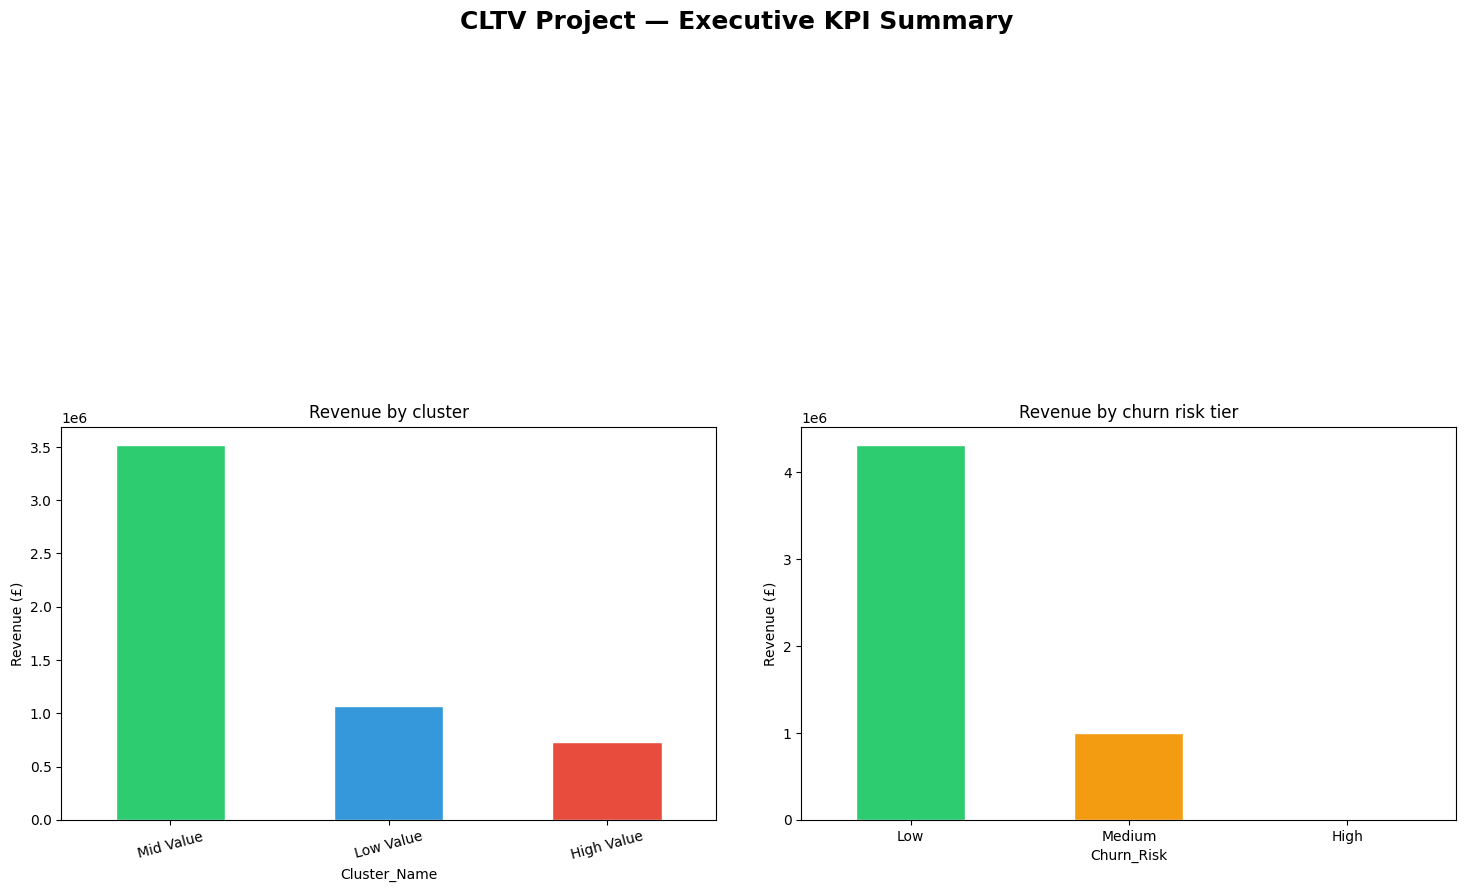

In [23]:
fig = plt.figure(figsize=(18, 9))
gs = gridspec.GridSpec(2, 4, figure=fig, height_ratios=[1, 2], hspace=0.35, wspace=0.3)

# KPI tiles (top row)
kpi_data = [
    ('Total customers',  f"{len(df):,}",             '#3498db'),
    ('Total revenue',    f"£{df['Monetary'].sum():,.0f}", '#2ecc71'),
    ('Avg CLTV',         f"£{df['CLTV'].mean():,.0f}",   '#9b59b6'),
    ('Overall churn rate', f"{df['Churned'].mean()*100:.1f}%", '#e74c3c'),
]

for i, (label, value, color) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center',
            fontsize=10, color='white', transform=ax.transAxes)
    ax.axis('off')

# Cluster revenue share (bottom left)
ax2 = fig.add_subplot(gs[1, :2])
cluster_rev = df.groupby('Cluster_Name')['Monetary'].sum().sort_values(ascending=False)
colors = ['#2ecc71', '#3498db', '#e74c3c']
cluster_rev.plot(kind='bar', ax=ax2, color=colors[:len(cluster_rev)],
                 edgecolor='white')
ax2.set_title('Revenue by cluster')
ax2.set_ylabel('Revenue (£)')
ax2.tick_params(axis='x', rotation=15)

# Churn risk breakdown (bottom right)
ax3 = fig.add_subplot(gs[1, 2:])
risk_rev = df.groupby('Churn_Risk')['Monetary'].sum().reindex(
    ['Low','Medium','High']
)
risk_rev.plot(kind='bar', ax=ax3,
              color=['#2ecc71','#f39c12','#e74c3c'],
              edgecolor='white')
ax3.set_title('Revenue by churn risk tier')
ax3.set_ylabel('Revenue (£)')
ax3.tick_params(axis='x', rotation=0)

plt.suptitle('CLTV Project — Executive KPI Summary', fontsize=18,
             fontweight='bold', y=1.01)
plt.savefig('../outputs/insights_kpi_summary.png',
            dpi=100, bbox_inches='tight')
plt.show()

In [27]:
df.to_csv('../outputs/customer_final.csv', index=False)
print("Updated customer_final.csv with Quadrant column")

insights_summary = df.groupby(['Cluster_Name', 'Churn_Risk']).agg(
    Customers      = ('CustomerID',        'count'),
    Avg_CLTV       = ('CLTV',              'mean'),
    Total_Revenue  = ('Monetary',          'sum'),
    Avg_ChurnProb  = ('Churn_Probability', 'mean'),
    Avg_Frequency  = ('Frequency',         'mean'),
).round(2).reset_index()

insights_summary.to_csv('../outputs/business_insights.csv', index=False)
print("Saved business_insights.csv")



Updated customer_final.csv with Quadrant column
Saved business_insights.csv
